# Neural Network Submodule 

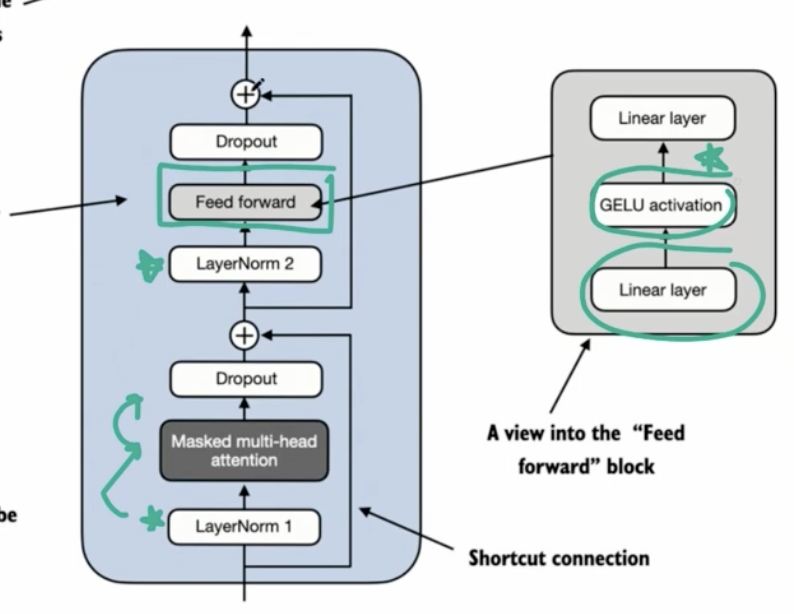

## Two activation functions commonly implemented in LLMs - GELU, SwiGLU

### RELU

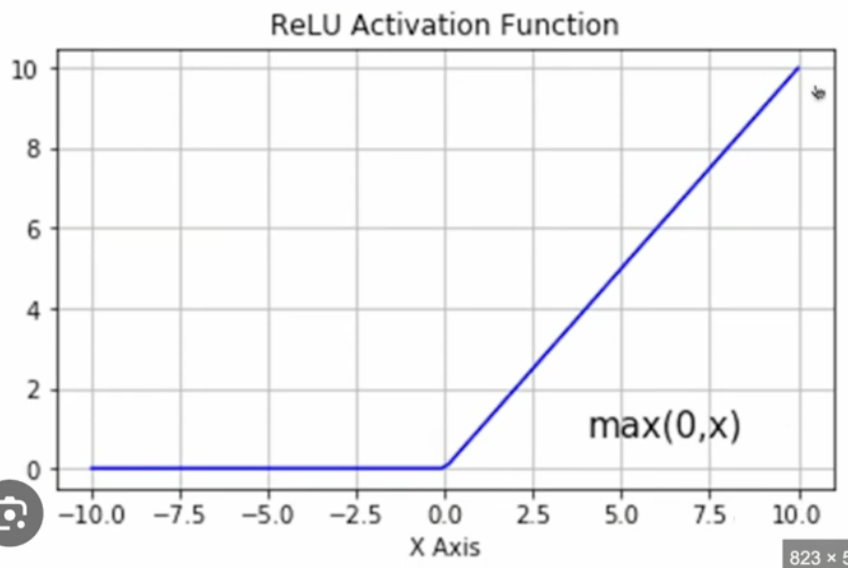

Problems - 

1. Non differentiable at 0
2. Dead neuron problem

### GELU

Gelu - x * CDF of standard Gaussian distribution

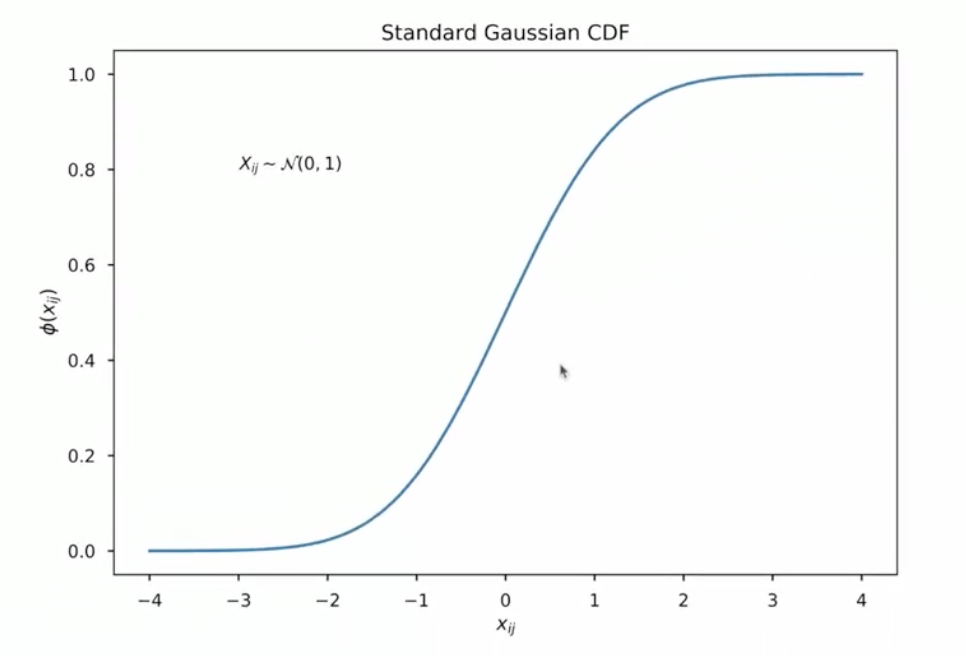

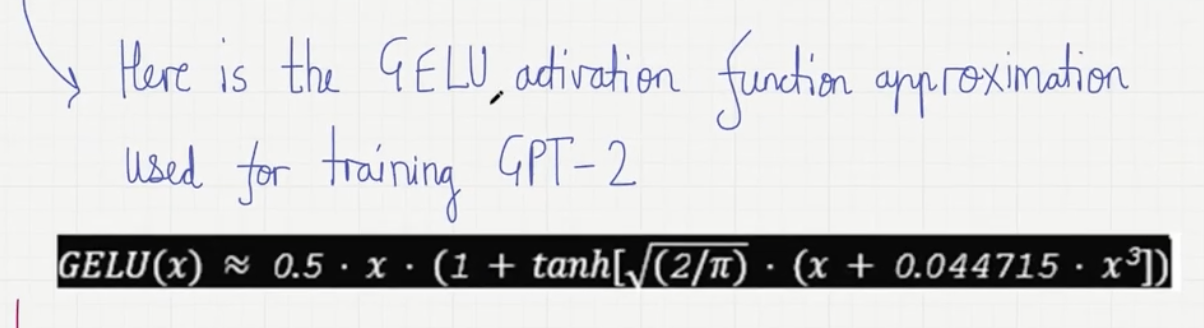

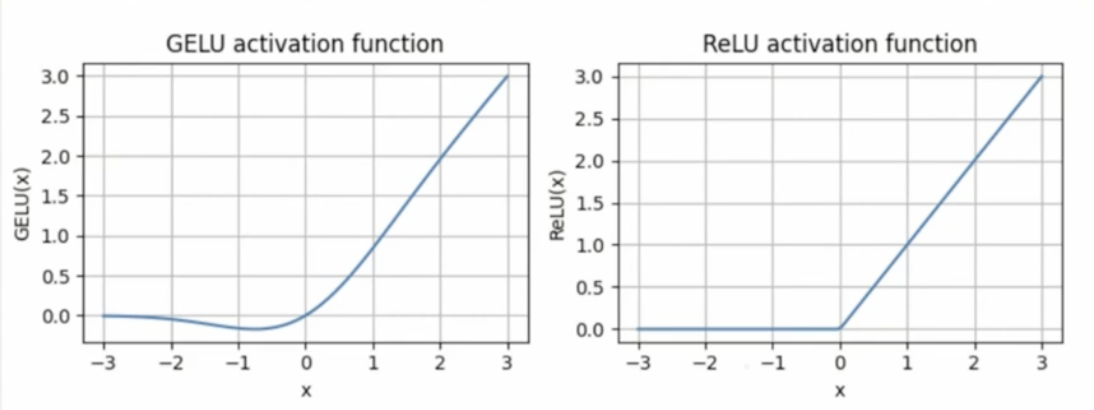

1. For high values of x - it tends to x as CDF tends to 1 which is similar to positive branch of Relu

2. For negative value , unlike Relu this is not 0 (this eliminate dead neuron problem)

3. It is differntiable unlike RELU 

In [1]:
import torch
import torch.nn as nn

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (

            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0/torch.pi)) * 
                (x+0.044715 * torch.pow(x,3))
            )
        )

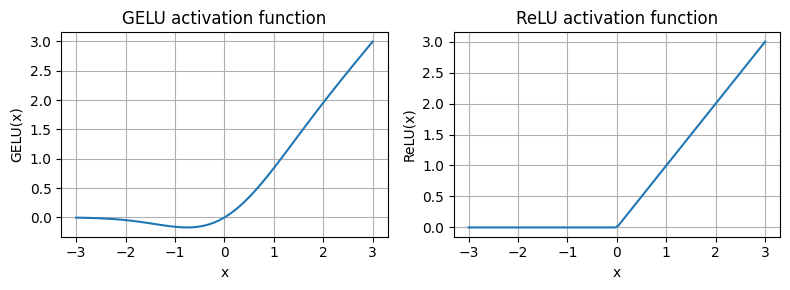

In [2]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

The smoothness of GELU, as shown in the above figure, can lead to better optimization properties
during training, as it allows for more nuanced adjustments to the model's parameters. 

In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder,
especially in networks that are very deep or have complex architectures. 

Moreover, unlike RELU, which outputs zero for any negative input, GELU allows for a small, non-zero output
for negative values. 

This characteristic means that during the training process, neurons that
receive negative input can still contribute to the learning process, albeit to a lesser extent
than positive inputs.

</div>

## Feedworward Network

Each token is processed independently unlike the attention

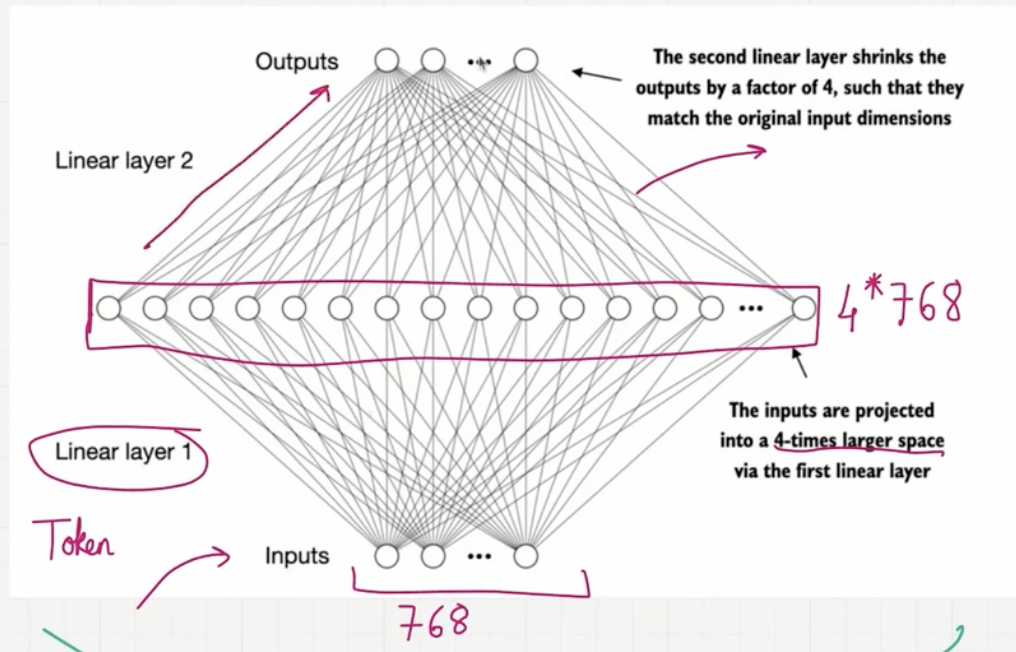

# Why Neural Networks Expand Dimensions

These are expansion and contraction neural networks. This allows a rich exploration space


🧩 Linear Separability Improves

1. In higher dimensions, complex patterns become easier to separate

2. 👉 This connects to
Cover's Theorem -“Data cast into higher-dimensional space is more likely to be linearly separable”


🎯 More Expressive Representations
Expansion allows the network to create new feature combinations
1. Example:
From 
[
𝑥
,
𝑦
]
 → can internally represent:
𝑥
𝑦
xy, 
𝑥<sup>2</sup>,
y<sup>2</sup>
, interactions, etc.

2. 👉 Without expansion, you're bottlenecked


🔀 Feature Interaction Space
1. Expansion enables interaction terms implicitly
2. Important for:
attention layers
MLP blocks in transformers


⚡ Non-linearity Becomes Powerful
1. Non-linear activations (ReLU, GELU) work better in higher dimensions
2. More “room” to carve decision boundaries


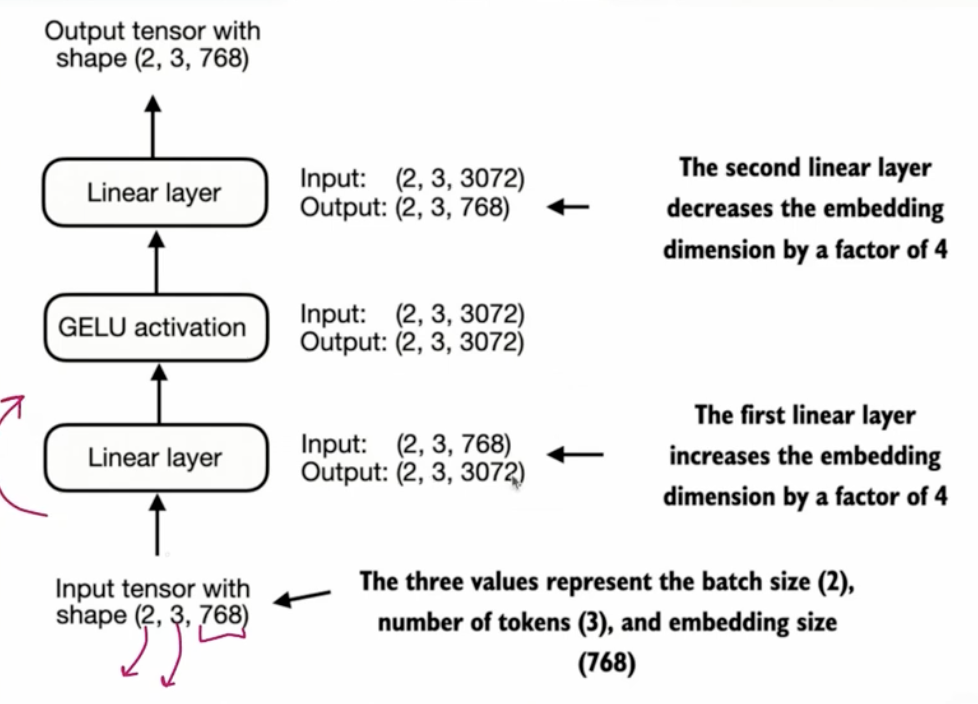



In [4]:
class FeedForward(nn.Module):

    def __init__(self,cfg):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]),
        )

    def forward(self,x):
        return self.layers(x)